In [24]:
#!pip install yfinance

In [25]:
import yfinance as yf
import pandas as pd
from IPython.display import display, HTML

display(HTML("<style>.container { width:90% ! important; }</style>"))

import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [26]:
indices_df = pd.read_csv('../data/global_indices_data.csv')
indices_df.head()


,Ticker,Name,Category
0,^GSPC,S&P 500,US Equities
1,^DJI,Dow Jones,US Equities
2,^IXIC,Nasdaq Composite,US Equities
3,^RUT,Russell 2000,US Equities
4,^VIX,CBOE Volatility Index,US Equities


In [27]:
#cob_date = '2025-04-01'  # Change this to the desired date
#cob_date = '2025-12-31'  # Change this to the desired date

cob_date = datetime.today().strftime('%Y-%m-%d')
cob_date_dt = datetime.strptime(cob_date, '%Y-%m-%d')
year_end_date = (cob_date_dt).replace(day=1, month=1) - timedelta(days=1)

print(f"Calculating for COB date: {cob_date}")
print(f"Year end date derived from COB date: {year_end_date.strftime('%Y-%m-%d')}")

Calculating for COB date: 2026-07-13
Year end date derived from COB date: 2025-12-31


In [28]:
index_types_list = indices_df['Category'].unique().tolist()
index_ticker_map = {}

for index_type in index_types_list:
    tickers = indices_df[indices_df['Category'] == index_type]['Ticker'].tolist()
    index_ticker_map[index_type] = tickers
index_ticker_map

{'US Equities': ['^GSPC', '^DJI', '^IXIC', '^RUT', '^VIX'],
 'US Cyclic Sectors ': ['XLB', 'XLI', 'XLK', 'XLY', 'XLF', 'XLC'],
 'US Defensive Sectors': ['XLRE', 'XLP', 'XLE', 'XLV', 'XLU'],
 'US Rates': ['^IRX', '^FVX', '^TNX', '^TYX'],
 'Europe Equities': ['^FTSE', '^FCHI', '^GDAXI'],
 'Asia Equities': ['000001.SS', '^N225', '^HSI', '^KS11', '^TWII', '^NSEI'],
 'FX - G5': ['EURUSD=X', 'JPY=X', 'GBPUSD=X', 'CHF=X'],
 'FX - Asia': ['USDCNY=X', 'INR=X', 'KRW=X', 'HKD=X', 'SGD=X'],
 'Commodity': ['CL=F', 'NG=F', 'GC=F', 'SI=F', 'HG=F'],
 'Crypto': ['BTC-USD', 'ETH-USD', 'SOL-USD', 'XRP-USD']}

In [29]:
ticker_names = indices_df.set_index('Ticker')['Name'].to_dict()
#ticker_names

In [30]:
# Function to fetch data
def fetch_data(tickers, start_dt, end_dt):
    df = yf.download(tickers, start=start_dt, end=end_dt)
    df = df['Close']
    return df

# Fetch data for all indices
#selected_timeframe = "Year to Date"  # Change this variable to adjust the timeframe
#period = timeframes[selected_timeframe]

dashboard_data = {}
for asset_class, tickers in index_ticker_map.items():
    dashboard_data[asset_class] = fetch_data(tickers, start_dt = f"{year_end_date.strftime('%Y-%m-%d')}", end_dt=cob_date)

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  4 of 4 completed


Asset Class: US Equities


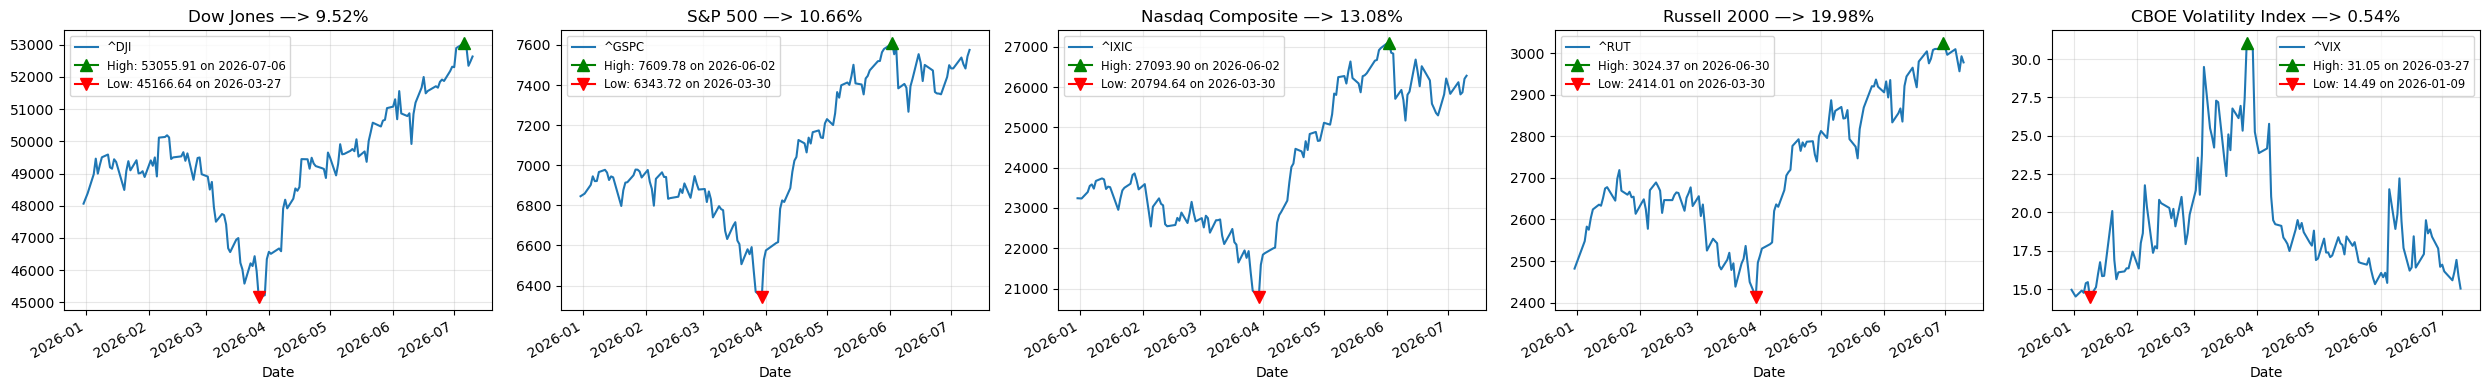

Asset Class: US Cyclic Sectors 


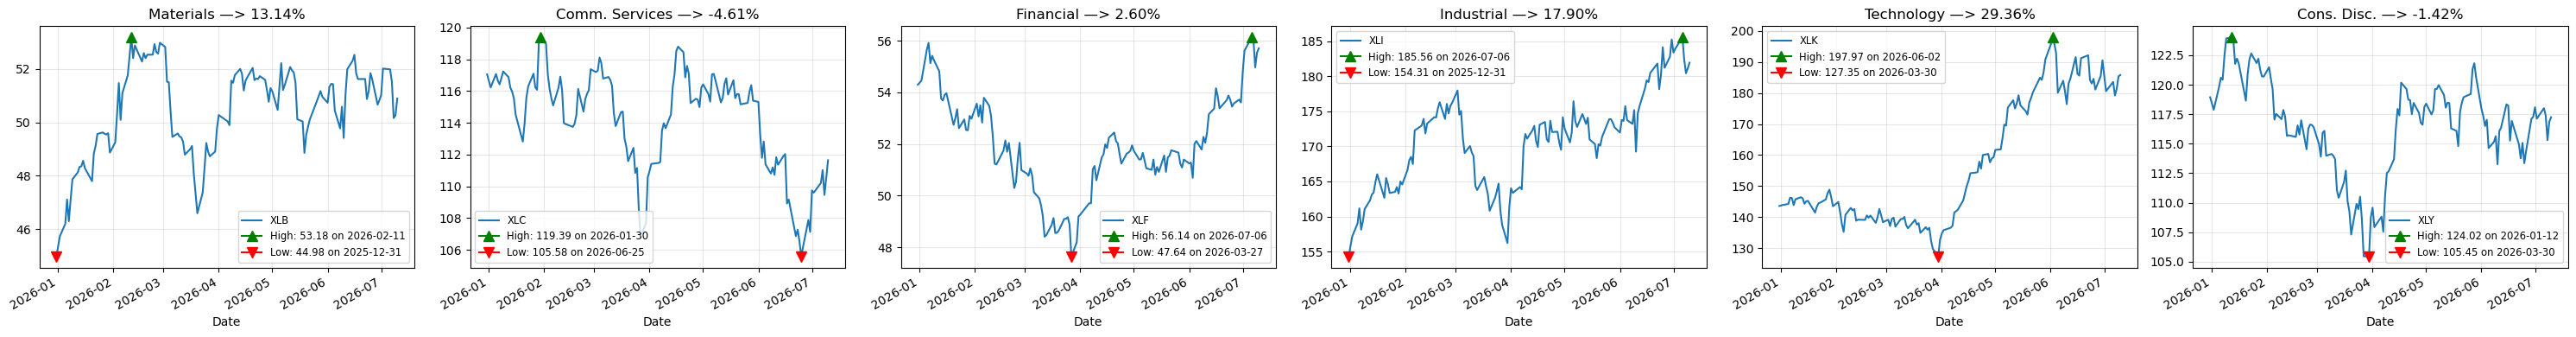

Asset Class: US Defensive Sectors


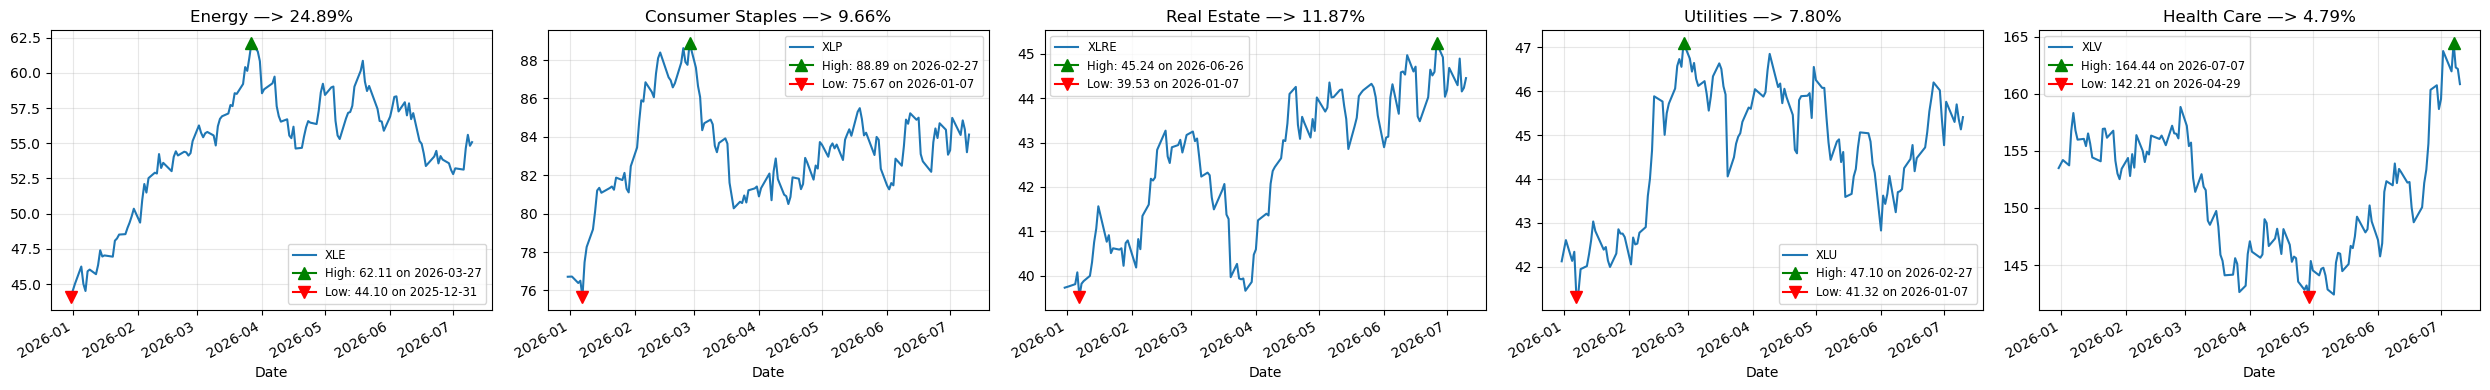

Asset Class: US Rates


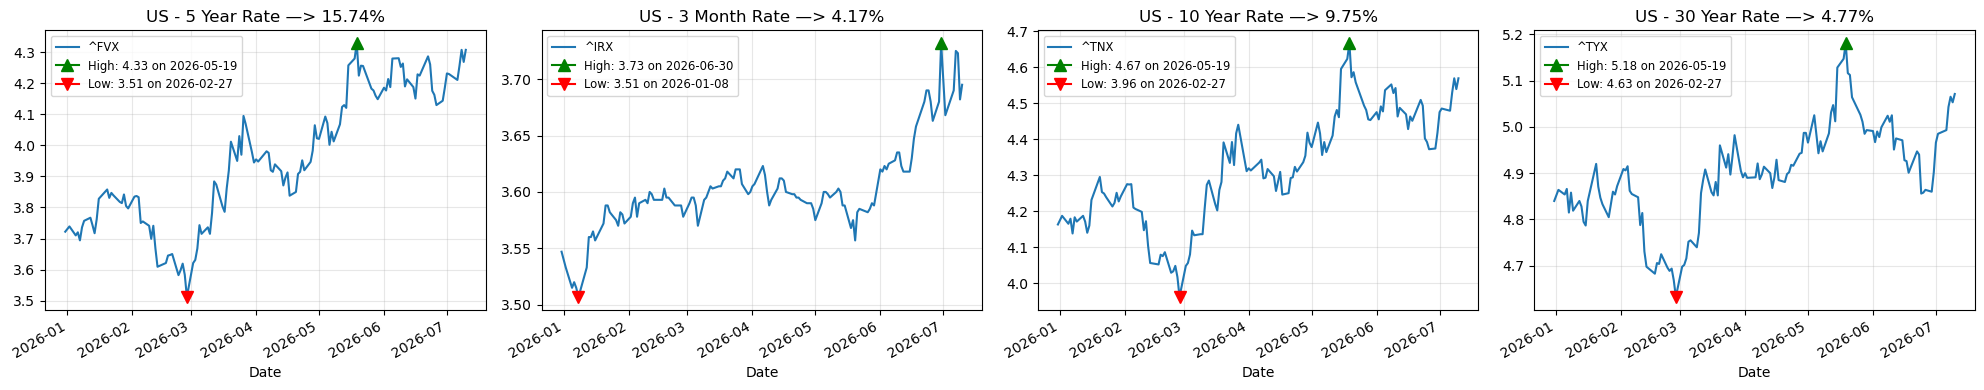

Asset Class: Europe Equities


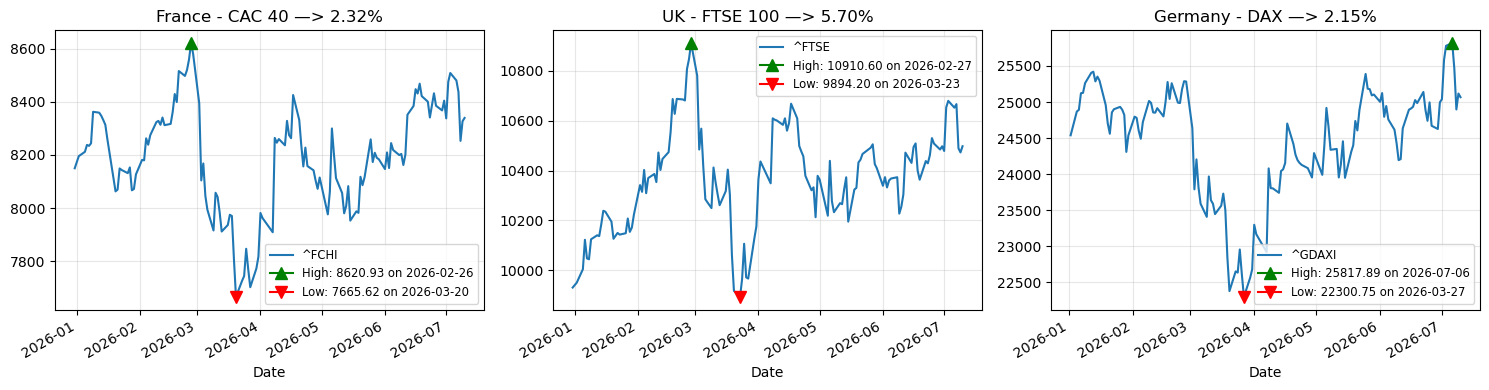

Asset Class: Asia Equities


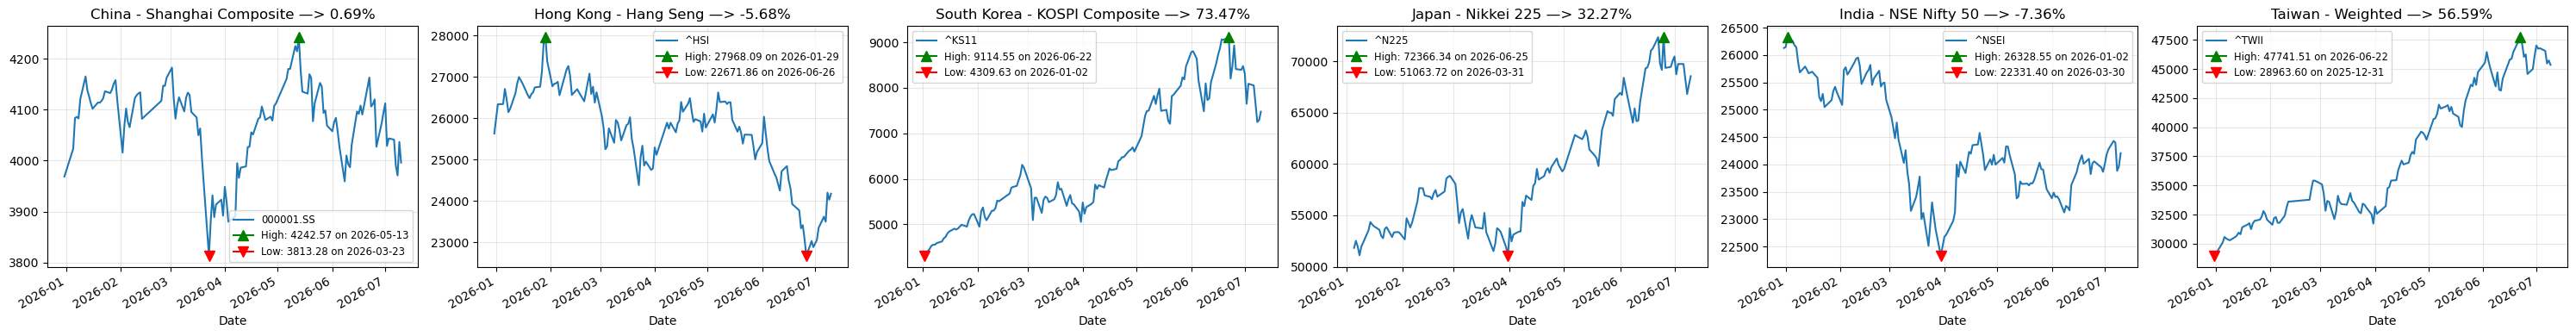

Asset Class: FX - G5


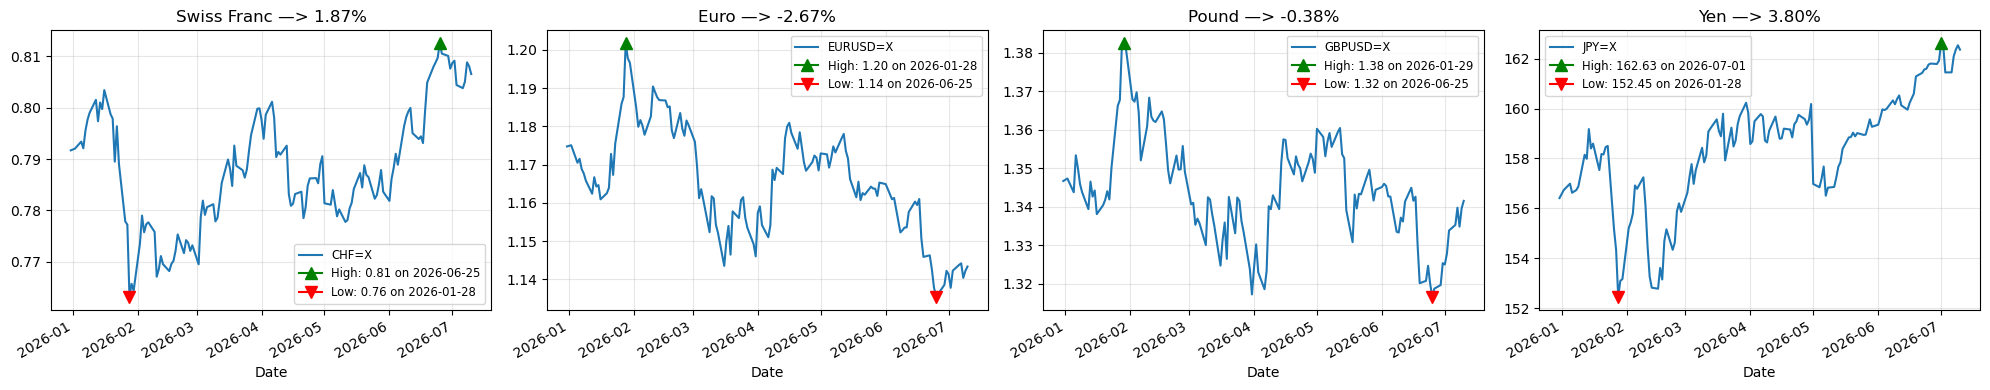

Asset Class: FX - Asia


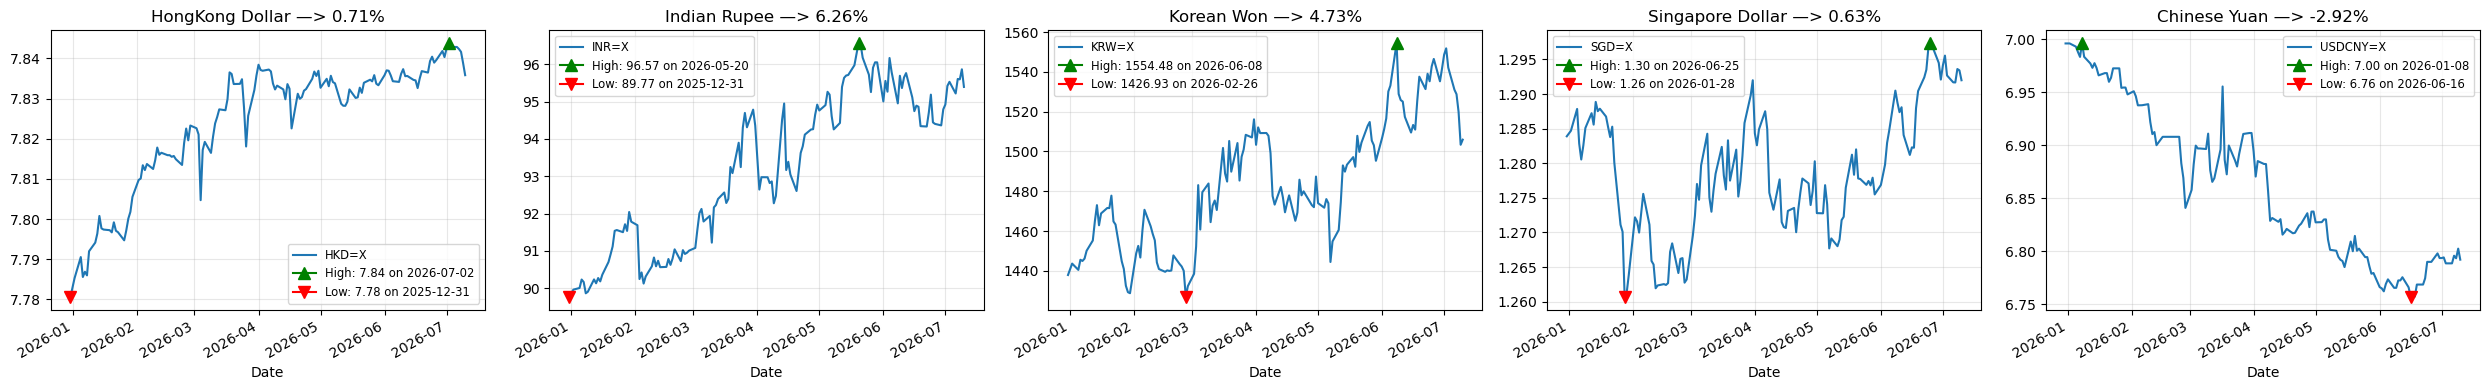

Asset Class: Commodity


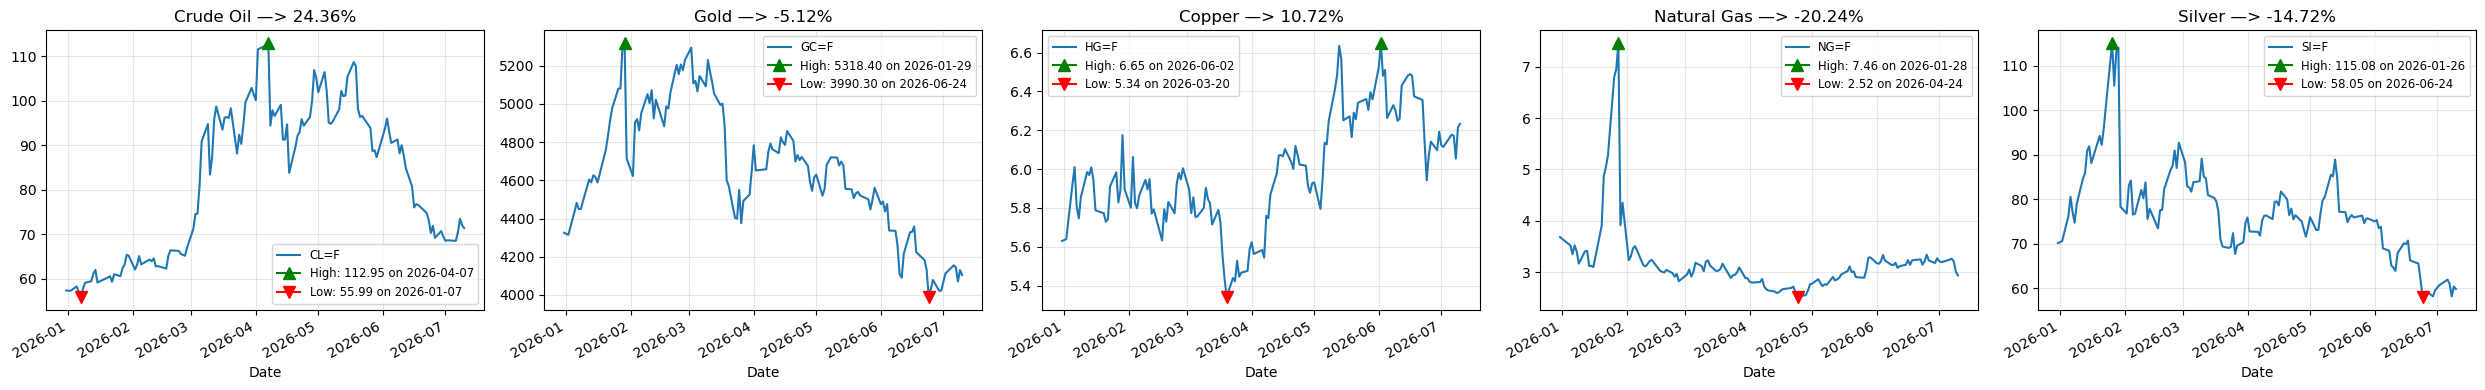

Asset Class: Crypto


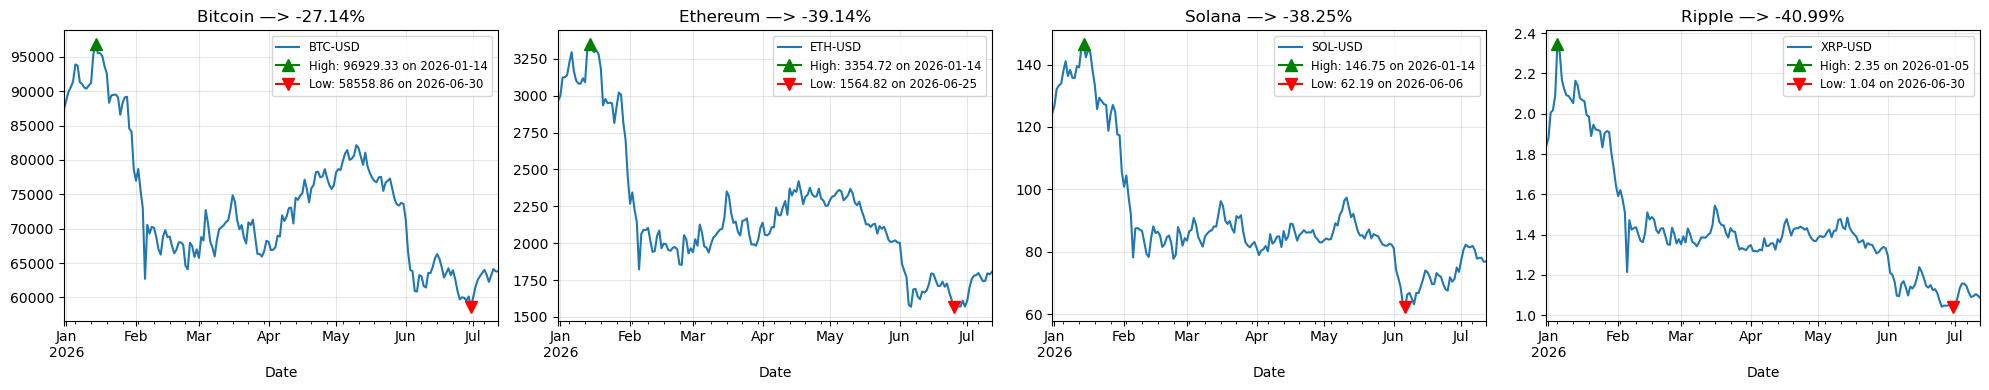

In [31]:
# Display data and charts
for asset_class, df in dashboard_data.items():
    print(f"Asset Class: {asset_class}")
    fig, axes = plt.subplots(ncols=len(df.columns), nrows=1, figsize=(5 * len(df.columns),4))

    # Normalize axes to a list when only one subplot exists
    axes_list = axes if hasattr(axes, '__len__') else [axes]

    for i, column in enumerate(df.columns):
        ax = axes_list[i]
        series = df[column].dropna()
        if series.empty:
            ax.set_title(ticker_names[column])
            continue

        # Ensure chronological order
        series = series.sort_index()

        # Compute percent return over the period (first available -> last available)
        try:
            start_val = series.iloc[0]
            end_val = series.iloc[-1]
            pct_return = (end_val / start_val - 1) * 100
        except Exception:
            pct_return = float('nan')

        # Plot series with percent return in title
        series.plot(ax=ax, title=f"{ticker_names[column]} —> {pct_return:.2f}%", xlabel=None)

        # Find high and low points
        high_idx = series.idxmax()
        high_val = series.max()
        low_idx = series.idxmin()
        low_val = series.min()

        # Plot markers for high and low
        ax.plot(high_idx, high_val, marker='^', color='green', markersize=8, label=f"High: {high_val:.2f} on {pd.to_datetime(high_idx).strftime('%Y-%m-%d')}")
        ax.plot(low_idx, low_val, marker='v', color='red', markersize=8, label=f"Low: {low_val:.2f} on {pd.to_datetime(low_idx).strftime('%Y-%m-%d')}")

        # Add legend and grid
        ax.legend(fontsize='small')
        ax.grid(alpha=0.3)

    plt.tight_layout()  # Adjust subplot spacing
    plt.show()

In [32]:
### for each of the indices that we are plotting, create a table that shows the following:
# - Index Name
# - Last 5 Day Return as of COB
# - Average 5 Day Return over the past 25 years
# - Standard Deviation of 5 Day Return over the past 5 years, annualized
# - (Best 5 day return) 100%ile 5 Day Return over the past 25 years and dates of when it occurred
# - (Worst 5 day return) 0%ile 5 Day Return over the past 25 years and dates of when it occurred
# - 99.5%ile 5 Day Return over the past 25 years and dates of when it occurred
# - 0.5%ile 5 Day Return over the past 25 years and dates of when it occurred

In [33]:
import numpy as np
from scipy import stats

# Fetch 25 years of historical data for all tickers
start_date_25yr = cob_date_dt - timedelta(days=25*365)
start_date_5yr = cob_date_dt - timedelta(days=5*365)

all_tickers = [ticker for tickers in index_ticker_map.values() for ticker in tickers]
historical_data = fetch_data(all_tickers, start_dt=start_date_25yr.strftime('%Y-%m-%d'), end_dt=cob_date)

# Calculate 5-day returns
five_day_returns = historical_data.pct_change(periods=5) * 100
five_day_returns_5yr = historical_data.pct_change(periods=5) * 100

# Create summary statistics for each index
for asset_class, tickers in index_ticker_map.items():
    print(f"\n{'='*180}")
    print(f"Asset Class: {asset_class}")
    print(f"{'='*180}\n")
    
    summary_data = []
    
    for ticker in tickers:
        ticker_5day_returns = five_day_returns[ticker].dropna()
        
        if len(ticker_5day_returns) == 0:
            continue
        
        # Last 5-day return
        last_5day_return = ticker_5day_returns.iloc[-1]
        
        # Average 5-day return
        avg_5day_return = ticker_5day_returns.mean()
        
        # Annualized standard deviation of 5-day returns over past 5 years
        ticker_5day_returns_5yr = five_day_returns_5yr[ticker].dropna()
        std_5day_return_5yr = ticker_5day_returns_5yr.std()
        annualized_std_5yr = std_5day_return_5yr * np.sqrt(252 / 5)
        
        # Best and worst 5-day returns with dates
        best_idx = ticker_5day_returns.idxmax()
        best_return = ticker_5day_returns.max()
        
        worst_idx = ticker_5day_returns.idxmin()
        worst_return = ticker_5day_returns.min()
        
        # 99.5%ile and 0.5%ile
        percentile_99_5 = np.percentile(ticker_5day_returns, 99.5)
        percentile_0_5 = np.percentile(ticker_5day_returns, 0.5)
        
        summary_data.append({
            'Index Name': ticker_names[ticker],
            'Last 5D Return (%)': last_5day_return,
            'Avg 5D Return (%)': avg_5day_return,
            'Annualized Std 5Y (%)': annualized_std_5yr,
            'Best 5D Return (%)': best_return,
            'Best Date': best_idx.strftime('%Y-%m-%d'),
            'Worst 5D Return (%)': worst_return,
            'Worst Date': worst_idx.strftime('%Y-%m-%d'),
            '99.5%ile Return (%)': percentile_99_5,
            '0.5%ile Return (%)': percentile_0_5
        })
    
    # Create and display DataFrame
    summary_df = pd.DataFrame(summary_data)
    display(summary_df.round(2))

[*********************100%***********************]  47 of 47 completed


Asset Class: US Equities



,Index Name,Last 5D Return (%),Avg 5D Return (%),Annualized Std 5Y (%),Best 5D Return (%),Best Date,Worst 5D Return (%),Worst Date,99.5%ile Return (%),0.5%ile Return (%)
0,S&P 500,0.95,0.14,15.69,17.97,2008-11-27,-18.34,2008-10-09,7.33,-7.89
1,Dow Jones,-0.54,0.13,15.16,17.62,2020-03-26,-18.16,2008-10-09,6.82,-7.36
2,Nasdaq Composite,1.79,0.20,18.76,16.41,2008-11-27,-17.57,2008-11-20,8.68,-8.34
3,Russell 2000,-0.16,0.16,20.36,21.68,2008-11-27,-22.51,2020-03-12,8.29,-9.66
4,CBOE Volatility Index,-6.82,0.88,101.74,175.63,2018-02-05,-47.19,2024-08-10,61.83,-30.05



Asset Class: US Cyclic Sectors 



,Index Name,Last 5D Return (%),Avg 5D Return (%),Annualized Std 5Y (%),Best 5D Return (%),Best Date,Worst 5D Return (%),Worst Date,99.5%ile Return (%),0.5%ile Return (%)
0,Materials,-1.20,0.17,20.08,21.70,2008-11-03,-21.63,2008-10-27,9.00,-9.85
1,Industrial,-0.25,0.18,18.31,20.75,2020-03-28,-19.42,2020-03-12,8.63,-9.74
2,Technology,3.68,0.23,19.90,18.05,2002-10-15,-15.87,2008-10-07,9.57,-9.37
3,Cons. Disc.,-0.13,0.19,19.11,23.58,2008-11-27,-19.41,2008-10-09,9.26,-9.07
4,Financial,-0.61,0.14,23.17,32.52,2009-03-13,-30.30,2008-10-09,12.06,-12.22
5,Comm. Services,0.56,0.18,17.05,11.05,2020-03-26,-14.93,2020-03-12,7.13,-8.21


...

,Index Name,Last 5D Return (%),Avg 5D Return (%),Annualized Std 5Y (%),Best 5D Return (%),Best Date,Worst 5D Return (%),Worst Date,99.5%ile Return (%),0.5%ile Return (%)
0,Chinese Yuan,-0.05,-0.01,2.96,9.78,2011-07-25,-9.19,2011-07-18,1.48,-1.49
1,Indian Rupee,-0.22,0.06,5.99,5.55,2013-08-22,-7.27,2013-09-11,3.24,-2.67
2,Korean Won,-1.49,0.03,10.03,17.46,2008-10-08,-13.26,2008-11-03,5.94,-4.83
3,HongKong Dollar,-0.08,0.00,0.60,2.06,2008-03-28,-1.36,2006-02-17,0.29,-0.32
4,Singapore Dollar,0.02,-0.02,4.50,5.01,2011-09-23,-4.19,2008-12-17,2.02,-1.85



Asset Class: Commodity



,Index Name,Last 5D Return (%),Avg 5D Return (%),Annualized Std 5Y (%),Best 5D Return (%),Best Date,Worst 5D Return (%),Worst Date,99.5%ile Return (%),0.5%ile Return (%)
0,Crude Oil,1.38,0.14,44.84,69.23,2020-04-26,-289.38,2020-04-20,17.94,-16.60
1,Natural Gas,-9.95,0.26,52.20,70.00,2026-01-23,-56.61,2026-02-02,24.11,-20.47
2,Gold,-0.99,0.20,15.84,20.42,2008-09-18,-13.45,2013-04-15,6.80,-7.55
3,Silver,-1.84,0.26,29.44,25.41,2008-09-23,-32.12,2026-02-02,13.00,-14.88
4,Copper,1.00,0.20,23.46,20.77,2011-10-27,-24.86,2025-07-31,10.33,-11.18



Asset Class: Crypto



,Index Name,Last 5D Return (%),Avg 5D Return (%),Annualized Std 5Y (%),Best 5D Return (%),Best Date,Worst 5D Return (%),Worst Date,99.5%ile Return (%),0.5%ile Return (%)
0,Bitcoin,0.73,0.89,55.46,61.63,2017-12-07,-44.21,2020-03-12,25.62,-22.88
1,Ethereum,2.11,0.78,71.67,65.27,2021-01-06,-52.77,2020-03-12,36.04,-30.09
2,Solana,-4.68,1.97,101.84,80.73,2020-08-12,-58.73,2022-11-09,60.47,-32.92
3,Ripple,-2.34,1.15,107.87,253.18,2017-12-14,-55.74,2020-12-23,80.89,-34.71
